
## Titanic Survival Prediction using Machine Learning

### This project predicts whether a passenger survived the Titanic disaster using machine learning. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model training, and performance evaluation.

### Import Libraries and Load Dataset

#### Import the required libraries and load the Titanic dataset for analysis.

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Dataset Overview

#### Examine the dataset structure, data types, summary statistics, and overall shape to understand the available information.

In [2]:
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


(891, 12)

### Check Missing Values

#### Identify missing values before performing data cleaning.

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Data Cleaning

#### Handle missing values by removing unnecessary columns and filling missing entries using appropriate statistical techniques.

In [4]:
df= df.drop('Cabin', axis=1)

In [5]:
print(df['Age'].mean())
print(df['Age'].median())

29.69911764705882
28.0


In [6]:
df['Age']= df['Age'].fillna(df['Age'].median())

In [7]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Feature Selection and Encoding

#### Remove irrelevant columns and convert categorical features into numerical values so they can be used by machine learning models.

In [9]:
df= df.drop(['PassengerId','Ticket','Name'],axis=1)

In [10]:
df['Sex']=df['Sex'].map({'male':0, 'female':1})

### Feature Engineering

#### Create a new feature named **FamilySize** by combining the number of siblings/spouses and parents/children traveling with each passenger.

In [11]:
df['FamilySize']= df['SibSp']+df['Parch']+1

### Exploratory Data Analysis (EDA)

#### Analyze relationships between different features and passenger survival using summary statistics.

In [12]:
df.groupby('Sex')['Survived'].mean()

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [13]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [14]:
df.groupby(['Pclass','Sex'])['Survived'].mean()

Pclass  Sex
1       0      0.368852
        1      0.968085
2       0      0.157407
        1      0.921053
3       0      0.135447
        1      0.500000
Name: Survived, dtype: float64

In [15]:
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [16]:
df['Pclass'].value_counts(normalize=True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [17]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [18]:
df['Embarked'].nunique()  

3

In [19]:
df['Sex'].unique()

array([0, 1])

In [20]:
df['Embarked']= df['Embarked'].map({'S':0,'C':1,'Q':2})

### Data Visualization

##### Visualize important patterns in the dataset using scatter plots, histograms, boxplots, bar charts, and a correlation heatmap.

In [21]:
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    int64  
 8   FamilySize  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


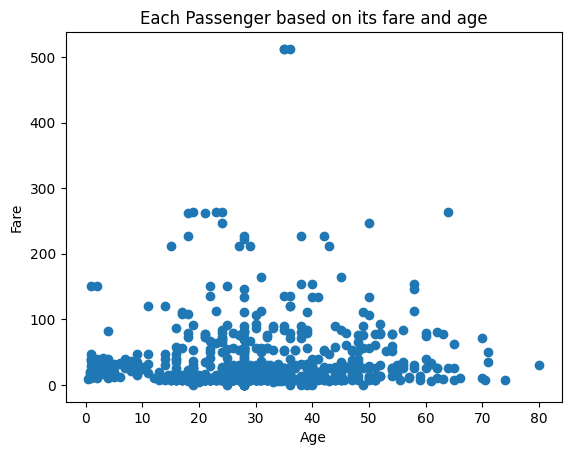

In [22]:
import matplotlib.pyplot as plt
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Each Passenger based on its fare and age")
plt.show()

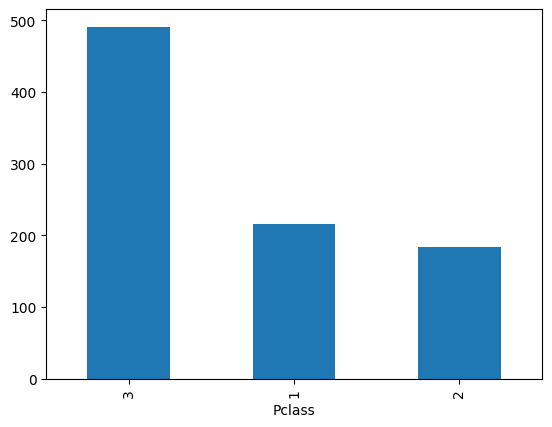

In [23]:
df['Pclass'].value_counts().plot(kind='bar')
plt.show()

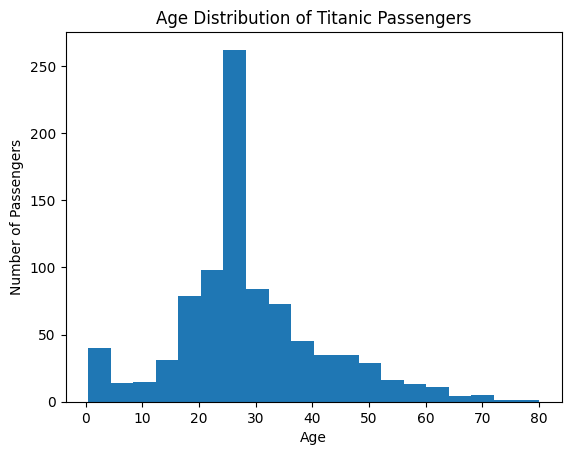

In [24]:
plt.hist(df['Age'], bins=20)
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

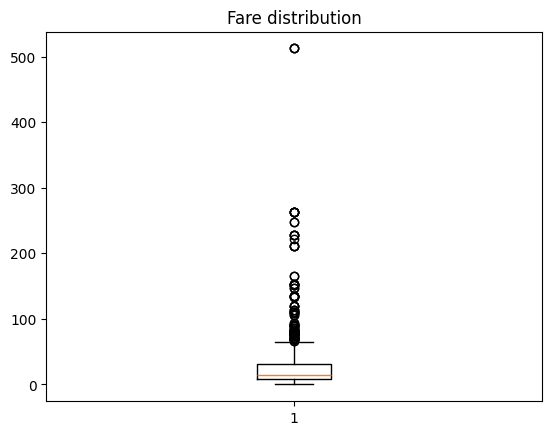

In [25]:
plt.boxplot(df['Fare'])
plt.title('Fare distribution')
plt.show()

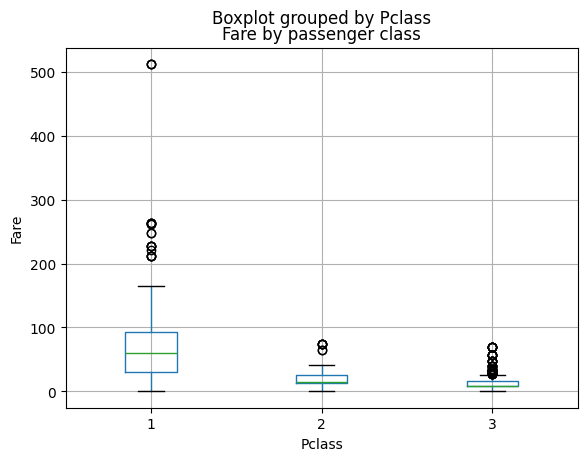

In [26]:
df.boxplot(column='Fare', by='Pclass')
plt.title("Fare by passenger class")
plt.ylabel("Fare")
plt.show()

### Feature and Target Selection

##### Separate the input features (X) from the target variable (Survived).

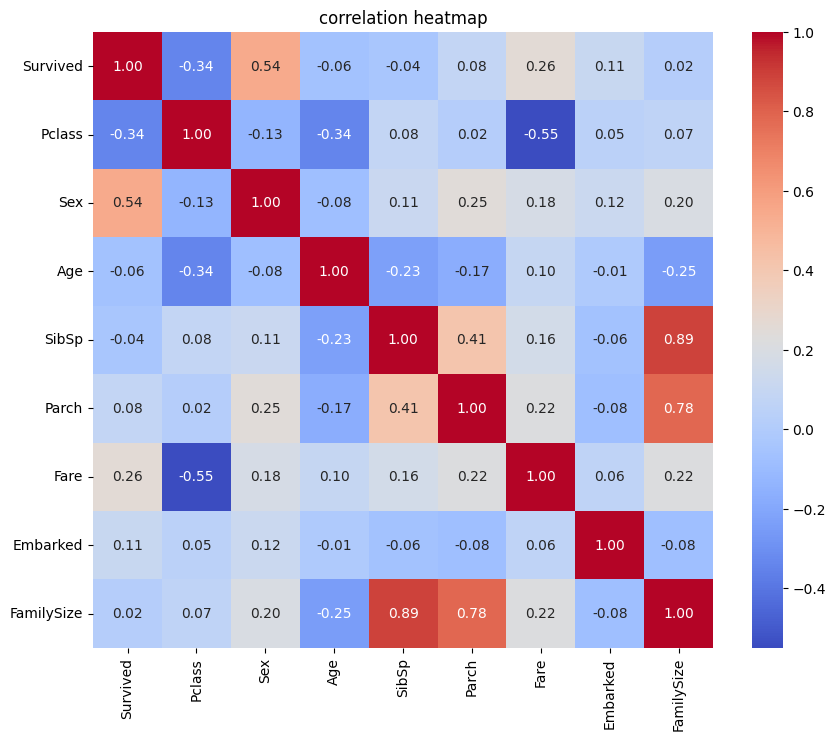

In [27]:
import seaborn as sns
correlation = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation,annot=True, cmap='coolwarm',fmt='.2f')
plt.title('correlation heatmap')
plt.show()

### Train-Test Split

#### Split the dataset into training and testing sets to evaluate model performance on unseen data.

In [28]:
X= df.drop('Survived', axis=1)
Y= df["Survived"]

### Logistic Regression

#### Train a Logistic Regression model, generate predictions, evaluate its performance, and examine the learned coefficients.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test= train_test_split(X,Y, test_size=0.2, random_state=1)

print(X_train.shape)
print(X_test.shape)

(712, 8)
(179, 8)


In [30]:
from sklearn.linear_model import LogisticRegression

model= LogisticRegression(max_iter=1000)

In [31]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
y_pred= model.predict(X_test)
print(y_pred[:10])
print(y_test[:10].values)

[1 0 1 1 1 0 0 1 1 1]
[1 0 1 0 1 0 0 1 0 1]


In [33]:
from sklearn.metrics import accuracy_score

accuracy= accuracy_score(y_test, y_pred)
print(accuracy)

0.7988826815642458


In [34]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

[[89 17]
 [19 54]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       106
           1       0.76      0.74      0.75        73

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [35]:
print(model.coef_) 
print(model.intercept_)  

[[-1.20623006e+00  2.58488069e+00 -3.94979159e-02 -2.42814711e-01
   1.47909620e-01  4.83419604e-04  2.70823867e-01 -9.80482143e-02]]
[2.48378052]


### Decision Tree Classifier

#### Train a Decision Tree model, evaluate its performance, and analyze feature importance.

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_model= DecisionTreeClassifier(random_state=42, criterion="gini", max_depth=3,min_samples_leaf=5)
dt_model.fit(X_train, y_train)
dt_pred=dt_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

print(accuracy_score(y_test,dt_pred))
print(confusion_matrix(y_test,dt_pred))
print(classification_report(y_test, dt_pred))

0.8044692737430168
[[95 11]
 [24 49]]
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       106
           1       0.82      0.67      0.74        73

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



In [38]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

      Feature  Importance
1         Sex    0.591257
0      Pclass    0.215429
2         Age    0.083802
7  FamilySize    0.062008
5        Fare    0.047503
3       SibSp    0.000000
4       Parch    0.000000
6    Embarked    0.000000


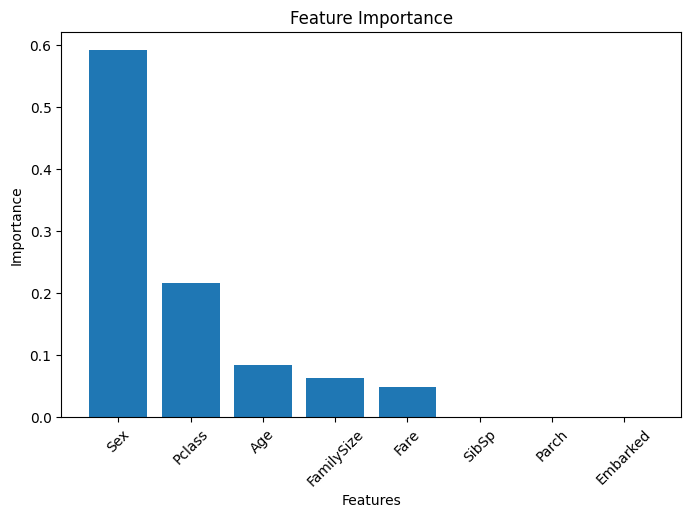

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

### Random Forest Classifier

##### Train a Random Forest model, evaluate its performance, and visualize feature importance.

In [40]:
from sklearn.ensemble import RandomForestClassifier

model= RandomForestClassifier(random_state=42,max_features="sqrt", n_estimators=100,min_samples_split=2, min_samples_leaf=3, max_depth=5)
model.fit(X_train,y_train)
y_pred= model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.770949720670391
[[98  8]
 [33 40]]
              precision    recall  f1-score   support

           0       0.75      0.92      0.83       106
           1       0.83      0.55      0.66        73

    accuracy                           0.77       179
   macro avg       0.79      0.74      0.74       179
weighted avg       0.78      0.77      0.76       179



In [42]:
importance= pd.DataFrame({
    'Feature':X.columns,
    "Importance": model.feature_importances_
})
importance= importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

      Feature  Importance
1         Sex    0.434545
5        Fare    0.165429
0      Pclass    0.143510
2         Age    0.112955
7  FamilySize    0.065686
3       SibSp    0.031439
6    Embarked    0.023268
4       Parch    0.023167


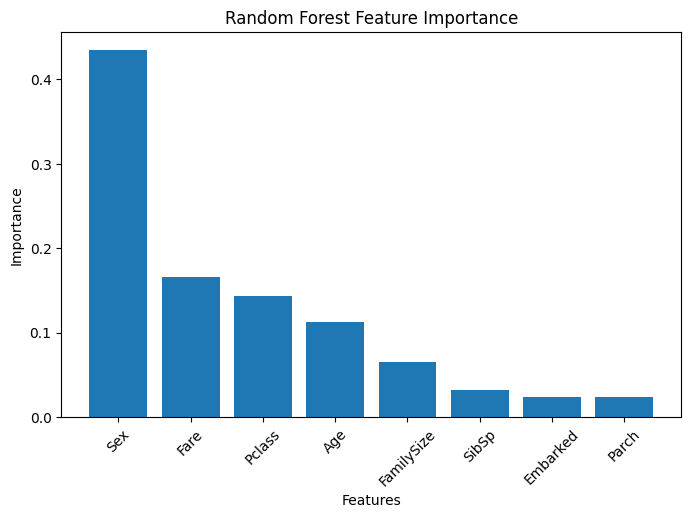

In [43]:
plt.figure(figsize=(8,5))

plt.bar(importance['Feature'],importance['Importance'])

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

### Model Comparison

#### Model                Accuracy
#### Logistic Regression    79%
#### Decision Tree          80%
#### Random Forest          80%

### Conclusion

#### The Titanic dataset was cleaned by handling missing values and encoding categorical features.
#### Exploratory Data Analysis (EDA) showed that Sex and Pclass had a strong relationship with passenger survival.
#### A new feature, FamilySize, was engineered to provide additional information to the models.
#### Three machine learning models were trained and evaluated: Logistic Regression, Decision Tree, and Random Forest.
#### Logistic Regression achieved an accuracy of 79%, while both Decision Tree and Random Forest achieved 80% on the test set.
#### Random Forest did not outperform the Decision Tree on this relatively small dataset, but it is generally more robust because it combines predictions from multiple decision trees.
#### Feature importance analysis showed that Sex was the most influential feature, followed by Fare, Pclass, and Age.